<a href="https://colab.research.google.com/github/reinanbr/colab_notebooks/blob/main/listas_de_Eletrodin%C3%A2mica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install ipympl

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

a)
$$ \nabla f(x,y,z) = (2x)i + (3y²)j + (4z³)k  $$

In [2]:
def f(x,y,z): return x**2 + y**3 + z**4

def gradf(x,y,z):
  return np.array([2*x, 3*y**2, 4*z**3])

n_termos = 50
z = np.linspace(-10,10,n_termos)
y = np.linspace(-10,10,n_termos)
x = np.linspace(-10,10,n_termos)



In [ ]:
grad = gradf(x,y,z)
gradf(x=1,y=1,z=1)



array([2, 3, 4])

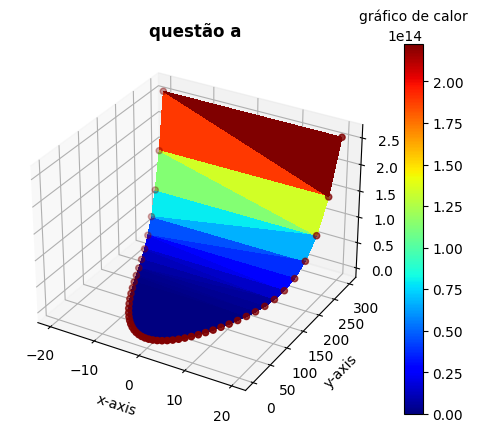

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')

X,Y,Z = gradf(x,y,z)
# X,Y,Z = np.meshgrid(X,Y,Z)
Z = np.array([f(x,y,z) for x,y,z in zip(np.ravel(X),np.ravel(Y),np.ravel(Z))])
norm = (X+Y+Z).sum()/np.sqrt(X**2+Y**2+Z**2)
m = cm.jet(norm)
# Z = zs.reshape(X.shape)

dx = np.gradient(X)
dy = np.gradient(Y)
dz = np.gradient(Z)

ax.plot_trisurf(X,Y,Z,linewidth=0,color='blue', antialiased=False)
cb = ax.plot_trisurf(X,Y,Z,linewidth=0,cmap = cm.jet, antialiased=False)

cbar = fig.colorbar(cb)

cbar.ax.set_title('gráfico de calor',fontsize=10)

ax.scatter(X,Y,Z,c=m)

ax.set_ylabel('y-axis')
ax.set_xlabel('x-axis')
ax.set_zlabel('z-axis')

ax.set_title('questão a',fontweight='bold')

plt.show()

<ipython-input-9-4006790b1e46>:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(X,Y,Z,c=cm_((nor(norm))),s=.3)
<ipython-input-9-4006790b1e46>:45: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(sm,fraction=0.026, pad=0.08)
<ipython-input-9-4006790b1e46>:47: UserWarning: FixedFormatter should only be used together with FixedLocator
  cbar.ax.set_yticklabels(ticklabs, fontsize=8)


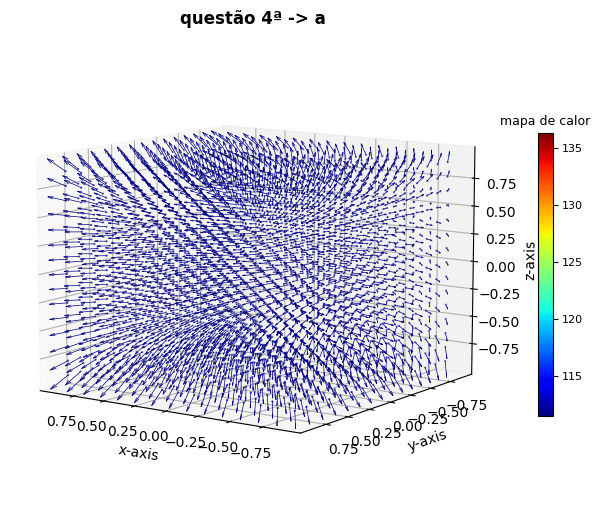

In [9]:

import sympy
import matplotlib
x,y,z=sympy.symbols('x y z')
fun = x**2 + y**3 + z**4


def f(x,y,z): return x**2 + y**3 + z**4



#take the gradient symbolically
gradfun=[sympy.diff(fun,var) for var in (x,y,z)]

#turn into a bivariate lambda for numpy
numgradfun=sympy.lambdify([x,y,z],gradfun)

space = np.linspace(-.9,.9,15)
X,Y,Z = np.meshgrid(space,space,space)

graddat=numgradfun(X,Y,Z)


fig = plt.figure(figsize=(7,7))
ax = fig.add_subplot(projection='3d')

norm = np.linalg.norm(graddat)
nor = matplotlib.colors.Normalize()
nor.autoscale(norm)

cm_ = matplotlib.cm.jet

sm = matplotlib.cm.ScalarMappable(cmap=cm_, norm=nor)
sm.set_array([])

ax.quiver(X,Y,Z,graddat[0],graddat[1],graddat[2], length=0.04, color = cm_((nor(norm))), lw=.5)


ax.scatter(X,Y,Z,c=cm_((nor(norm))),s=.3)
ax.set_ylabel('y-axis')
ax.set_xlabel('x-axis')
ax.set_zlabel('z-axis')

ax.set_title('questão 4ª -> a',fontweight='bold')

cbar = plt.colorbar(sm,fraction=0.026, pad=0.08)
ticklabs = cbar.ax.get_yticklabels()
cbar.ax.set_yticklabels(ticklabs, fontsize=8)
cbar.ax.set_title('mapa de calor',fontsize=9)

x,y,z = gradf(X,Y,Z)
ax.view_init(10, 125)
plt.show()

<ipython-input-3-3be171b1e2a7>:20: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(color_map,fraction=0.026, pad=0.04)


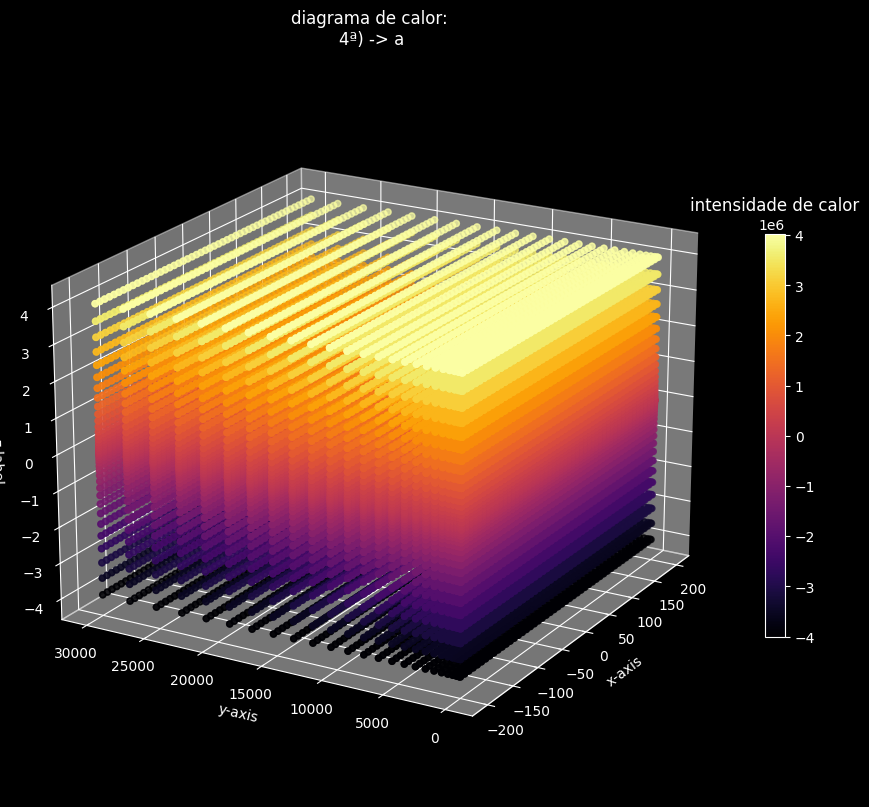

In [3]:
t = np.linspace(-100,100,50)
x,y,z = np.meshgrid(t,t,t)
X,Y,Z = gradf(x,y,z)
colo = X+Y+Z
color_map = cm.ScalarMappable(cmap=cm.inferno)
color_map.set_array(colo)
plt.style.use('dark_background')
# creating figures
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X,Y,Z,c=colo,cmap=cm.inferno)

ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-label')

ax.set_title('diagrama de calor: \n4ª) -> a\n')

cbar = plt.colorbar(color_map,fraction=0.026, pad=0.04)
cbar.ax.set_title('intensidade de calor')
ax.view_init(20, 210)
plt.show()

<ipython-input-5-6a9379744f4e>:32: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(color_map, fraction=0.026, pad=0.04)  # Adjust fraction value


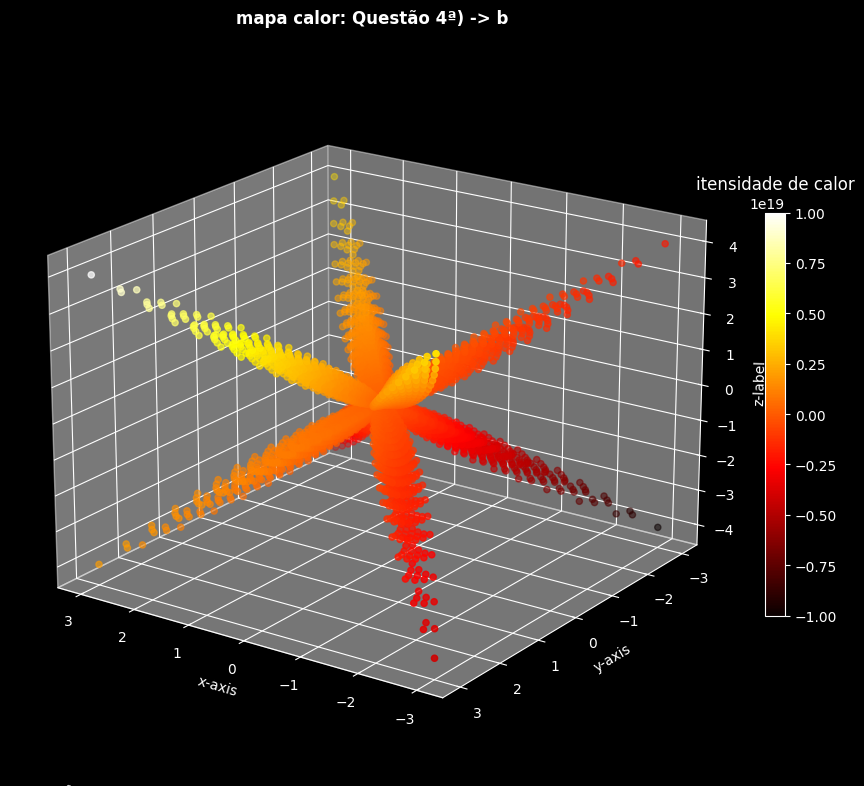

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm



def gradf2(x, y, z):
    return np.array([(3*x**2)*(y**3)*(z**4), (x**3)*(3*y**2)*(z**4), (x**3)*(y**3)*(4*z**3)])

t = np.linspace(-100, 100, 50)
x, y, z = np.meshgrid(t, t, t)
X, Y, Z = gradf2(x, y, z)
colo = X + Y + Z  # Remove the list brackets

color_map = cm.ScalarMappable(cmap=cm.hot)
color_map.set_array(colo)

# creating figures
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Use scatter3D instead of scatter for 3D scatter plots
ax.scatter3D(X, Y, Z, c=colo,cmap=cm.hot)  # Use scatter3D here

ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-label')

ax.set_title('mapa calor: Questão 4ª) -> b\n'+'', fontweight='bold')

cbar = plt.colorbar(color_map, fraction=0.026, pad=0.04)  # Adjust fraction value
cbar.ax.set_title('itensidade de calor')
ax.view_init(20, 125)
plt.show()


<ipython-input-7-3f6056ff954a>:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(color_map, fraction=0.046, pad=0.04)  # Adjust fraction value


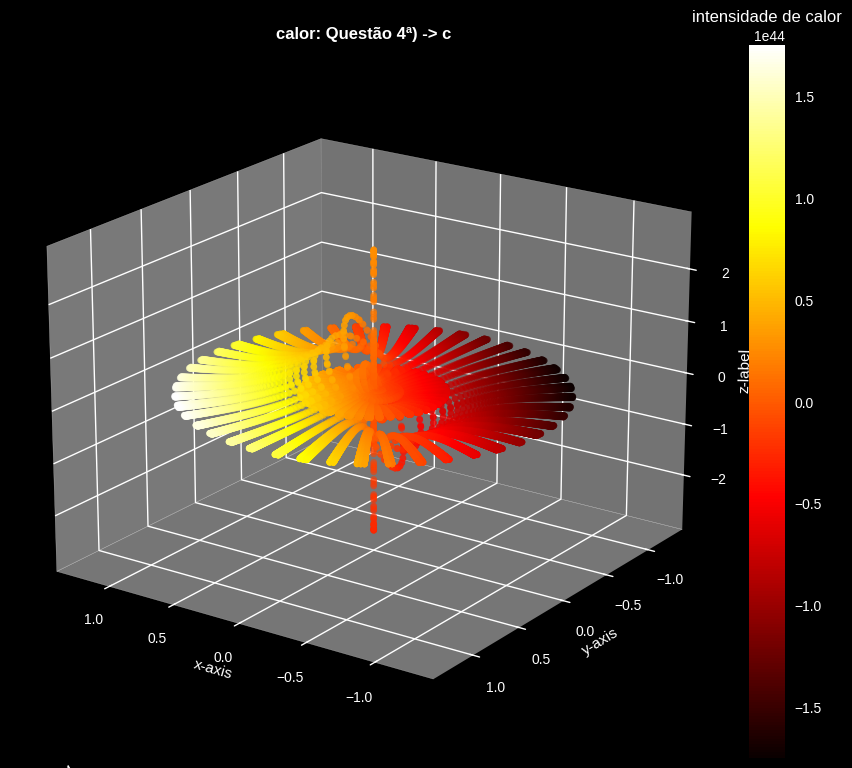

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
plt.style.use('dark_background')
def gradf3(x, y, z):
    return np.array([np.exp(x)*np.sin(y)*np.log(z), np.exp(x)*np.cos(y)*np.log(z), (np.exp(x)*np.sin(y))/z])

t = np.linspace(1, 100, 100)
x, y, z = np.meshgrid(t, t, t)
X, Y, Z = gradf3(x, y, z)
colo = X + Y + Z  # Remove the list brackets

color_map = cm.ScalarMappable(cmap=cm.hot)
color_map.set_array(colo)

# creating figures
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Use scatter3D instead of scatter for 3D scatter plots
ax.scatter3D(X, Y, Z, c=colo,cmap=cm.hot)  # Use scatter3D here

ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-label')

ax.set_title('calor: Questão 4ª) -> c', fontweight='bold')

cbar = plt.colorbar(color_map, fraction=0.046, pad=0.04)  # Adjust fraction value
cbar.ax.set_title('intensidade de calor')
ax.view_init(20,125)
plt.show()


<ipython-input-53-e93cb8a01a19>:30: MatplotlibDeprecationWarning: Unable to determine Axes to steal space for Colorbar. Using gca(), but will raise in the future. Either provide the *cax* argument to use as the Axes for the Colorbar, provide the *ax* argument to steal space from it, or add *mappable* to an Axes.
  cbar = plt.colorbar(color_map, fraction=0.046, pad=0.04)  # Adjust fraction value


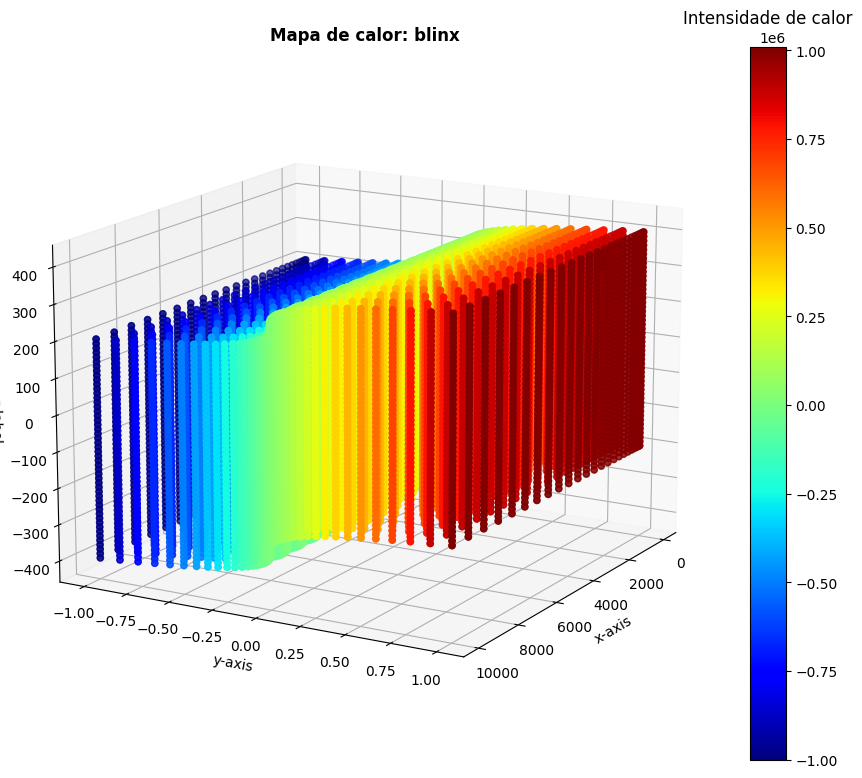

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

def gradf3(x, y, z):
    return np.array([x**2, y**3, y-z*3])

t = np.linspace(-100, 100, 50)
x, y, z = np.meshgrid(t, t, t)
X, Y, Z = gradf3(x, y, z)
colo = X + Y + Z  # Remove the list brackets

color_map = cm.ScalarMappable(cmap=cm.jet)
color_map.set_array(colo)

# creating figures
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Use scatter3D instead of scatter for 3D scatter plots
ax.scatter3D(X, Y, Z, c=colo,cmap=cm.jet)  # Use scatter3D here

ax.set_xlabel('x-axis')
ax.set_ylabel('y-axis')
ax.set_zlabel('z-label')

ax.set_title('Mapa de calor: blinx', fontweight='bold')

cbar = plt.colorbar(color_map, fraction=0.046, pad=0.04)  # Adjust fraction value
cbar.ax.set_title('Intensidade de calor')
ax.view_init(15, 30)
plt.show()


$$  $$